# Transport in sector-specific hydrogen markets

Compare transport activity and impacts from 2030 to 2050 for **1 kg of hydrogen, gaseous, low pressure** supplied by one sector market. Edit the settings below, then run all cells. All tables and plots stay inline; there are no exports.

This notebook reuses `LCIA_mapping_h2.py` and the calculation/stage helpers in `run_analysis.py`. Production is calculated for reconciliation, but excluded from the plotted distribution results. Transport includes the upstream burdens of the mapped transport services. The existing stage helper separates mapped pipeline compression and direct H₂/NH₃ leakage; other embedded service inputs remain in the service footprint. This is a mapped contribution analysis, not a decomposition of every upstream transport activity in the economy.


In [10]:
from pathlib import Path
import sys
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bw2data as bd
from IPython.display import display

# Same module-resolution pattern as the existing analysis notebooks.
candidates = [Path.cwd(), Path.cwd().parent,
              Path.cwd() / "examples" / "h2-distribution_LCIA"]
ANALYSIS_DIR = next(p.resolve() for p in candidates
                    if (p / "LCIA_mapping_h2.py").exists())
sys.path.insert(0, str(ANALYSIS_DIR))
import config as cfg
import LCIA_mapping_h2 as mapping
from run_analysis import (select_methods, calculate_lcia,
                          analyze_hydrogen_life_cycle_stages)

plt.rcParams.update({"font.size": 10, "axes.titlesize": 11})


## 1. Settings and available databases

Choose an existing project and run the next cell to list its mapped databases for the requested years. Then select database names in the following cell. The general mapping remains unchanged; databases absent from this project are simply excluded.

Steel is the initial sector. Region selection tries EUR first, then WEU. Change these settings for another geographical scope. Missing years remain gaps; a missing 2030 database prevents normalization for that scenario but does not prevent absolute plots.


In [11]:
PROJECT = "ecoinvent-3.12-cutoff"
SECTOR = "Transport"
REGION = "EUR"
REGION_FALLBACKS = ("WEU",)
BASE_YEAR = 2030
YEARS = [2030, 2040, 2050]

assert SECTOR in cfg.EXPECTED_SECTOR_MARKETS
assert BASE_YEAR in YEARS and len(YEARS) == len(set(YEARS))
if PROJECT not in bd.projects:
    raise LookupError(f"Existing Brightway project required: {PROJECT}")
bd.projects.set_current(PROJECT)
available_records = [dict(item) for item in mapping.DATABASES
                     if item["database"] in bd.databases and item["year"] in YEARS]
if not available_records:
    raise LookupError("No mapped databases for these years are available in this project.")
print(f"Mapped databases available in {PROJECT}:")
display(pd.DataFrame(available_records))
print("Project databases without mapping metadata (not selectable here):")
print(sorted(set(bd.databases) - {item["database"] for item in mapping.DATABASES}))


Mapped databases available in ecoinvent-3.12-cutoff:


,database,iam_model,scenario,year
0,ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2...,remind,SSP2-PkBudg1000,2030
1,ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2...,remind,SSP2-PkBudg1000,2040
2,ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2...,remind,SSP2-PkBudg1000,2050
3,ecoinvent-3.12-cutoff_image-SSP2-VLHO_2030_08_...,image,SSP2-VLHO,2030
4,ecoinvent-3.12-cutoff_image-SSP2-VLHO_2040_08_...,image,SSP2-VLHO,2040
5,ecoinvent-3.12-cutoff_image-SSP2-VLHO_2050_08_...,image,SSP2-VLHO,2050
6,ecoinvent-3.12-cutoff_message-SSP2-L_2030_08_full,message,SSP2-L,2030
7,ecoinvent-3.12-cutoff_message-SSP2-L_2040_08_full,message,SSP2-L,2040
8,ecoinvent-3.12-cutoff_message-SSP2-L_2050_08_full,message,SSP2-L,2050


Project databases without mapping metadata (not selectable here):
['biosphere-3.12', 'ecoinvent-3.12-cutoff', 'ecoinvent-3.12-cutoff_SSP1-L-image_2050', 'ecoinvent-3.12-cutoff_SSP1-L-message_2050', 'ecoinvent-3.12-cutoff_SSP1-VL-message_2050', 'ecoinvent-3.12-cutoff_SSP2-M-image_2050', 'ecoinvent-3.12-cutoff_SSP2-M-image_2050_1', 'ecoinvent-3.12-cutoff_SSP2-M-message_2050', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2030_04_full', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2030_05_full', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2050', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2050_01', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2050_02', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2050_03', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2050_04_full', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2050_05-1_full', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2050_05-2_full', 'ecoinvent-3.12-cutoff_SSP2-NDC-remind_2050_05_full', 'ecoinvent-3.12-cutoff_SSP2-RCP19-tiam_2050_1', 'ecoinvent-3.12-cutoff_SSP2-RCP26-tiam_2050', 'ecoinve

In [12]:
# None selects all available mapped databases shown above.
# To choose a subset, replace None with a list of exact database names from the table.
SELECTED_DATABASES = [
    'ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2030_08_full',
    'ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full',
    'ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2050_08_full',
]
if bd.projects.current != PROJECT:
    raise RuntimeError("Project changed: rerun the settings cell before selecting databases.")
names = ([item["database"] for item in available_records]
         if SELECTED_DATABASES is None else list(SELECTED_DATABASES))
if not names or len(names) != len(set(names)):
    raise ValueError("Select at least one database, with no duplicate names.")
allowed = {item["database"] for item in available_records}
unknown = set(names) - (allowed & set(bd.databases))
if unknown:
    raise ValueError(f"Select names from the available database table: {sorted(unknown)}")
records = [dict(item, label=mapping.SCENARIO_LABELS[(item["iam_model"], item["scenario"])])
           for item in available_records if item["database"] in names]
keys = [(r["iam_model"], r["scenario"], r["year"]) for r in records]
if len(keys) != len(set(keys)):
    raise ValueError("Select only one database per scenario/year.")
SCENARIOS = list(dict.fromkeys((r["iam_model"], r["scenario"]) for r in records))
scenario_labels = {key: mapping.SCENARIO_LABELS[key] for key in SCENARIOS}
for label in scenario_labels.values():
    selected_years = {r["year"] for r in records if r["label"] == label}
    if BASE_YEAR not in selected_years:
        warnings.warn(f"{label}: no selected {BASE_YEAR} database; absolute plots only.")
display(pd.DataFrame(records))


,database,iam_model,scenario,year,label
0,ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2...,remind,SSP2-PkBudg1000,2030,REMIND - SSP2-PkBudg1000
1,ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2...,remind,SSP2-PkBudg1000,2040,REMIND - SSP2-PkBudg1000
2,ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2...,remind,SSP2-PkBudg1000,2050,REMIND - SSP2-PkBudg1000


## 1b. Available sector markets by region and year

Run this check before the LCIA calculation. It lists all matching sector-market names in the selected databases at the preferred region and its fallbacks. The summary shows the location that would be selected (preferred region first), missing markets, duplicate matches, and years without a selected database. Generic markets are excluded. No LCIA is run.

Use the sector labels in the summary to choose `SECTOR` above. Newly discovered names without a configured sector label are listed by their suffix and need an entry in `cfg.EXPECTED_SECTOR_MARKETS` before the existing analysis selector can use them.


In [ ]:
if bd.projects.current != PROJECT:
    raise RuntimeError("Project changed: rerun section 1 before checking sector availability.")

regions = list(dict.fromkeys((REGION, *REGION_FALLBACKS)))
prefix = cfg.GENERIC_MARKET_NAME + ", "
market_labels = {name: label for label, name in cfg.EXPECTED_SECTOR_MARKETS.items()}
market_rows = []
for record in records:
    for activity in bd.Database(record["database"]):
        name = activity.get("name", "")
        location = activity.get("location")
        if (name.startswith(prefix) and location in regions
                and activity.get("reference product") == cfg.REFERENCE_PRODUCT
                and activity.get("unit") == cfg.UNIT):
            market_rows.append({
                "scenario": record["label"], "year": record["year"],
                "database": record["database"], "market name": name,
                "sector": market_labels.get(name, name[len(prefix):]),
                "location": location, "activity key": activity.key,
            })
sector_markets = pd.DataFrame(market_rows, columns=[
    "scenario", "year", "database", "market name", "sector", "location", "activity key"])
print("Matching sector markets (including available fallback locations):")
display(sector_markets.sort_values(["scenario", "year", "sector", "location"]))

# Include known sectors even if absent throughout, plus any additional names found.
all_names = list(dict.fromkeys([*market_labels, *sector_markets["market name"]]))
selected_pairs = {(r["label"], r["year"]) for r in records}
availability_rows = []
for scenario in scenario_labels.values():
    for year in YEARS:
        for name in all_names:
            status = "Not available"
            if (scenario, year) not in selected_pairs:
                status = "No selected database"
            else:
                matches = sector_markets.loc[
                    (sector_markets["scenario"] == scenario)
                    & (sector_markets["year"] == year)
                    & (sector_markets["market name"] == name)]
                for location in regions:
                    count = int(matches["location"].eq(location).sum())
                    if count:
                        status = location if count == 1 else f"Ambiguous: {count} at {location}"
                        break
            availability_rows.append({
                "scenario": scenario, "year": year,
                "sector": market_labels.get(name, name[len(prefix):]),
                "market name": name, "availability": status,
            })
sector_availability = pd.DataFrame(availability_rows)
print("Availability by year (entries show the selected region):")
display(sector_availability.pivot(
    index=["scenario", "sector", "market name"], columns="year", values="availability"
).reindex(columns=YEARS))


## 2. Select markets and calculate contributions

The small selector below follows the exact-name/product/unit selection in the existing runner, but only selects our sector. No generic RER market is required. An absent sector market is reported as unavailable; duplicate matches raise an error. The existing stage helper checks that production plus distribution reconstructs the market total for every method.


In [13]:
def select_sector(database):
    candidates = [a for a in database
                  if a.get("name") == cfg.EXPECTED_SECTOR_MARKETS[SECTOR]
                  and a.get("reference product") == cfg.REFERENCE_PRODUCT
                  and a.get("unit") == cfg.UNIT]
    for location in dict.fromkeys((REGION, *REGION_FALLBACKS)):
        matches = [a for a in candidates if a.get("location") == location]
        if len(matches) > 1:
            raise LookupError(f"Multiple {SECTOR} markets at {location} in {database.name}")
        if matches:
            return matches[0]
    return None

if PROJECT not in bd.projects:
    raise LookupError(f"Existing Brightway project required: {PROJECT}")
bd.projects.set_current(PROJECT)
_, methods, method_units, method_table = select_methods()
display(method_table)
missing = [r["database"] for r in records if r["database"] not in bd.databases]
if missing:
    raise LookupError(f"Mapped databases are unavailable: {missing}")

selection_rows, distribution_frames, activity_frames, checks = [], [], [], []
for record in records:
    print(f'{record["label"]} — {record["year"]}')
    market = select_sector(bd.Database(record["database"]))
    metadata = {"scenario": record["label"], "year": record["year"],
                "database": record["database"],
                "location": market.get("location") if market is not None else None}
    selection_rows.append(dict(metadata, status="available" if market is not None else "unavailable",
                               activity_key=market.key if market is not None else None))
    if market is None:
        continue
    selected = {SECTOR: market}
    scores, _ = calculate_lcia(selected, [SECTOR], methods, method_units)
    for index, method in enumerate(methods):
        stage = analyze_hydrogen_life_cycle_stages(
            selected, [SECTOR], method, scores,
            mapping.impact_category_label(method), method_units[method],
            functional_unit=1.0, reconciliation_rtol=cfg.RECONCILIATION_RTOL,
        )
        distribution_frames.append(stage["distribution processes"].assign(**metadata))
        checks.append(stage["reconciliation"].assign(**metadata))
        # Physical demands are method-independent: collect them once.
        if index == 0:
            audit = stage["classification audit"]
            activity_frames.append(audit.loc[
                (audit["stage"] == "Distribution") & (audit["substage"] == "Transport")
            ].assign(**metadata))

selection = pd.DataFrame(selection_rows)
display(selection)
if not distribution_frames:
    raise ValueError("No selected sector markets are available in the requested regions.")
distribution = pd.concat(distribution_frames, ignore_index=True)
activities = pd.concat(activity_frames, ignore_index=True)
reconciliation = pd.concat(checks, ignore_index=True)
display(reconciliation[["scenario", "year", "impact category",
                        "Layer 1 difference", "Layer 2 difference"]])
for scenario, group in selection.groupby("scenario"):
    if group["location"].dropna().nunique() > 1:
        warnings.warn(f"{scenario}: selected region changes across years; inspect selection.")


,method,impact category,indicator,unit
0,"(EF v3.1, acidification, accumulated exceedanc...",acidification,accumulated exceedance (AE),mol H+-Eq
1,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H2","GWP 100a, incl. H",kg CO2-Eq
2,"(EF v3.1, ecotoxicity: freshwater, comparative...",ecotoxicity: freshwater,comparative toxic unit for ecosystems (CTUe),CTUe
3,"(EF v3.1, energy resources: non-renewable, abi...",energy resources: non-renewable,abiotic depletion potential (ADP): fossil fuels,"MJ, net calorific value"
4,"(EF v3.1, eutrophication: freshwater, fraction...",eutrophication: freshwater,fraction of nutrients reaching freshwater end ...,kg P-Eq
5,"(EF v3.1, eutrophication: marine, fraction of ...",eutrophication: marine,fraction of nutrients reaching marine end comp...,kg N-Eq
6,"(EF v3.1, human toxicity: carcinogenic, compar...",human toxicity: carcinogenic,comparative toxic unit for human (CTUh),CTUh
7,"(EF v3.1, human toxicity: non-carcinogenic, co...",human toxicity: non-carcinogenic,comparative toxic unit for human (CTUh),CTUh
8,"(EF v3.1, material resources: metals/minerals,...",material resources: metals/minerals,abiotic depletion potential (ADP): elements (u...,kg Sb-Eq
9,"(EF v3.1, particulate matter formation, impact...",particulate matter formation,impact on human health,disease incidence


REMIND - SSP2-PkBudg1000 — 2030
REMIND - SSP2-PkBudg1000 — 2040
REMIND - SSP2-PkBudg1000 — 2050


,scenario,year,database,location,status,activity_key
0,REMIND - SSP2-PkBudg1000,2030,ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2...,EUR,available,(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_...
1,REMIND - SSP2-PkBudg1000,2040,ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2...,EUR,available,(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_...
2,REMIND - SSP2-PkBudg1000,2050,ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2...,EUR,available,(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_...


,scenario,year,impact category,Layer 1 difference,Layer 2 difference
0,REMIND - SSP2-PkBudg1000,2030,acidification,4.530590e-10,6.440270e-10
1,REMIND - SSP2-PkBudg1000,2030,"climate change — GWP 100a, incl. H2",-3.952865e-08,-2.223402e-08
2,REMIND - SSP2-PkBudg1000,2030,ecotoxicity: freshwater,4.643216e-07,6.855572e-07
3,REMIND - SSP2-PkBudg1000,2030,energy resources: non-renewable,9.448076e-07,1.499727e-06
4,REMIND - SSP2-PkBudg1000,2030,eutrophication: freshwater,2.020172e-11,3.102928e-11
5,REMIND - SSP2-PkBudg1000,2030,eutrophication: marine,6.121511e-11,8.830583e-11
6,REMIND - SSP2-PkBudg1000,2030,human toxicity: carcinogenic,4.280412e-17,6.878712e-17
7,REMIND - SSP2-PkBudg1000,2030,human toxicity: non-carcinogenic,2.534592e-15,4.119911e-15
8,REMIND - SSP2-PkBudg1000,2030,material resources: metals/minerals,1.834782e-12,2.982278e-12
9,REMIND - SSP2-PkBudg1000,2030,particulate matter formation,2.907183e-15,4.327001e-15


## 3. Prepare transport and distribution views

Transport excludes separately identified leakage, conversion and reconversion. Physical quantities are service demands per kg H₂, not hydrogen mode shares: tonne-kilometres combine mass and distance, while a pipeline service may use another unit. Units are never added together.

Normalized values divide **total transport impact** by the same scenario/category's 2030 total. Values below 1 mean lower impacts only for a positive baseline. Zero/negative baselines and missing years stay unavailable. Region changes relative to the baseline are flagged in the table.


In [14]:
transport = distribution.loc[
    (distribution["substage"] == "Transport")
    & (distribution["contribution type"] == "Process excluding leakage")
].copy()
mode_order = list(dict.fromkeys(mapping.TRANSPORT_NAMES.values()))
mode_colors = {mode: mapping.ROUTE_COLORS[mapping.distribution_family(mode)]
               for mode in mode_order}
mode_hatches = {mode: mapping.FAMILY_STYLES[mapping.distribution_family(mode)]["hatch"]
                for mode in mode_order}
labels = list(scenario_labels.values())
categories = [mapping.impact_category_label(m) for m in methods]
units = {mapping.impact_category_label(m): method_units[m] for m in methods}
available = selection.loc[selection["status"] == "available", ["scenario", "year", "location"]]

# Start with every available market/method, so a genuine absence of transport is zero.
totals = available.merge(pd.DataFrame({"impact category": categories}), how="cross")
summed = transport.groupby(["scenario", "year", "impact category"], as_index=False)["score"].sum()
totals = totals.merge(summed, how="left", on=["scenario", "year", "impact category"])
totals["score"] = totals["score"].fillna(0.0)
baseline = totals.loc[totals["year"] == BASE_YEAR,
                      ["scenario", "impact category", "score", "location"]].rename(
    columns={"score": "baseline", "location": "baseline location"})
totals = totals.merge(baseline, on=["scenario", "impact category"], how="left",
                      validate="many_to_one")
valid = np.isfinite(totals["baseline"]) & (totals["baseline"] > 0)
totals["normalized"] = totals["score"] / totals["baseline"].where(valid)
totals["region changed"] = (totals["baseline location"].notna()
                            & totals["location"].ne(totals["baseline location"]))
display(totals)


,scenario,year,location,impact category,score,baseline,baseline location,normalized,region changed
0,REMIND - SSP2-PkBudg1000,2030,EUR,acidification,3.329984e-04,3.329984e-04,EUR,1.000000,False
1,REMIND - SSP2-PkBudg1000,2030,EUR,"climate change — GWP 100a, incl. H2",6.449105e-02,6.449105e-02,EUR,1.000000,False
2,REMIND - SSP2-PkBudg1000,2030,EUR,ecotoxicity: freshwater,4.787599e-01,4.787599e-01,EUR,1.000000,False
3,REMIND - SSP2-PkBudg1000,2030,EUR,energy resources: non-renewable,1.417501e+00,1.417501e+00,EUR,1.000000,False
4,REMIND - SSP2-PkBudg1000,2030,EUR,eutrophication: freshwater,1.270845e-05,1.270845e-05,EUR,1.000000,False
5,REMIND - SSP2-PkBudg1000,2030,EUR,eutrophication: marine,9.190728e-05,9.190728e-05,EUR,1.000000,False
6,REMIND - SSP2-PkBudg1000,2030,EUR,human toxicity: carcinogenic,2.919831e-11,2.919831e-11,EUR,1.000000,False
7,REMIND - SSP2-PkBudg1000,2030,EUR,human toxicity: non-carcinogenic,1.347231e-09,1.347231e-09,EUR,1.000000,False
8,REMIND - SSP2-PkBudg1000,2030,EUR,material resources: metals/minerals,8.541173e-07,8.541173e-07,EUR,1.000000,False
9,REMIND - SSP2-PkBudg1000,2030,EUR,particulate matter formation,3.240527e-09,3.240527e-09,EUR,1.000000,False


## 4. Transport activity quantities

Each panel uses one native unit. Lines distinguish mapped transport modes; missing markets create gaps. Selected locations appear alongside the year labels.


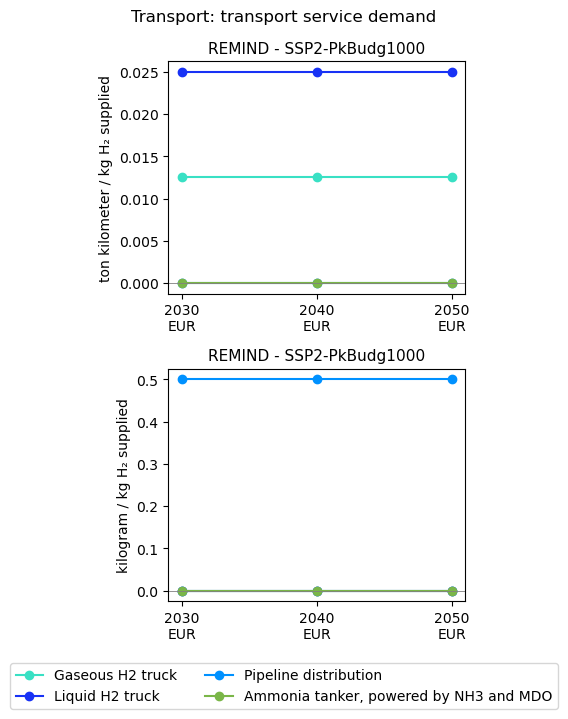

In [15]:
def year_labels(scenario):
    locations = selection.loc[selection["scenario"] == scenario].set_index("year").reindex(YEARS)
    return [f"{year}\n{locations.loc[year, 'location'] if pd.notna(locations.loc[year, 'location']) else 'N/A'}" for year in YEARS]

def available_years(scenario):
    return available.loc[available["scenario"] == scenario, "year"].tolist()

if activities.empty:
    print("No mapped transport service demands in the selected markets.")
else:
    activity_units = activities["provider unit"].drop_duplicates().tolist()
    fig, axes = plt.subplots(len(activity_units), len(labels), squeeze=False,
                             figsize=(4 * len(labels), 3.3 * len(activity_units)),
                             sharey="row")
    for row, unit in enumerate(activity_units):
        for col, scenario in enumerate(labels):
            ax = axes[row, col]
            for mode in mode_order:
                part = activities.loc[(activities["scenario"] == scenario)
                    & (activities["provider unit"] == unit) & (activities["component"] == mode)]
                values = part.groupby("year")["demand amount"].sum().reindex(YEARS, fill_value=0.0)
                values.loc[~values.index.isin(available_years(scenario))] = np.nan
                ax.plot(range(len(YEARS)), values, marker="o", label=mode, color=mode_colors[mode])
            ax.set_title(scenario)
            ax.set_xticks(range(len(YEARS)), year_labels(scenario))
            if col == 0:
                ax.set_ylabel(f"{unit} / kg H₂ supplied")
            ax.axhline(0, color="0.5", lw=0.6)
    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 0), ncol=2)
    fig.suptitle(f"{SECTOR}: transport service demand")
    fig.tight_layout()
    plt.show()


## 5. Absolute transport impacts

One 16:9 figure per model/scenario, with all ten impact categories in a 2 × 5 grid. The title includes the mapped warming label, sector and preferred region. Years appear below each panel. Categories retain the same limits across scenarios. Colors/hatches identify transport modes, diamonds show signed totals, and N/A indicates missing markets. Actual selected regions remain available in the selection table.


In [ ]:
def plot_stacks(frame, group_column, groups, colors, hatches, title):
    # Match the spider/contribution notebook typography, locally to these figures.
    style = {"font.family": "sans-serif", "font.size": 15,
             "axes.titlesize": 13, "axes.labelsize": 13,
             "xtick.labelsize": 11, "ytick.labelsize": 11,
             "legend.fontsize": 11, "legend.title_fontsize": 12,
             "figure.titlesize": 18}
    # All categories share one 16:9 figure per scenario.
    with plt.rc_context(style):
        for scenario in labels:
            scenario_key = next(key for key, label in scenario_labels.items() if label == scenario)
            warming = mapping.WARMING_MAP[scenario_key]
            fig, axes = plt.subplots(math.ceil(len(categories) / 5), 5, figsize=(16, 9), squeeze=False)
            x = np.arange(len(YEARS))
            exists = np.array([y in available_years(scenario) for y in YEARS])
            for ax, category in zip(axes.flat, categories):
                # Shared category limits across scenarios preserve comparability.
                part = frame.loc[frame["impact category"] == category]
                all_values = part.groupby(["scenario", "year", group_column])["score"].sum().unstack(group_column)
                positions = [(s, y) for s in labels for y in YEARS]
                all_values = all_values.reindex(pd.MultiIndex.from_tuples(
                    positions, names=["scenario", "year"]))
                all_values = all_values.reindex(columns=groups).fillna(0.0)
                low = min(0.0, float(all_values.clip(upper=0).sum(axis=1).min()))
                high = max(0.0, float(all_values.clip(lower=0).sum(axis=1).max()))
                padding = 0.08 * (high - low) if high > low else 0.05
                pivot = all_values.loc[scenario].reindex(YEARS)
                positive, negative = np.zeros(len(x)), np.zeros(len(x))
                for group in groups:
                    values = pivot[group].to_numpy()
                    bottom = np.where(values >= 0, positive, negative)
                    ax.bar(x, np.where(exists, values, np.nan), bottom=bottom,
                           color=colors[group], hatch=hatches.get(group, ""),
                           label=group, width=0.7)
                    positive += np.maximum(values, 0)
                    negative += np.minimum(values, 0)
                ax.plot(x, np.where(exists, pivot.sum(axis=1), np.nan), "kD", ms=3)
                ax.set_ylim(low - padding if low < 0 else 0, high + padding)
                for i in np.flatnonzero(~exists):
                    ax.text(i, 0, "N/A", ha="center", va="bottom", fontsize=11)
                ax.set_xticks(x, [str(y) for y in YEARS])
                # Wrap category titles to fit the five-column layout.
                from textwrap import fill
                ax.set_title(fill(category, width=22))
                ax.set_ylabel(f"{units[category]} / kg H₂")
                ax.axhline(0, color="0.4", lw=0.6)
            for ax in list(axes.flat)[len(categories):]:
                ax.set_visible(False)
            handles, legend_labels = axes.flat[0].get_legend_handles_labels()
            fig.legend(handles, legend_labels, loc="lower center",
                       bbox_to_anchor=(0.5, 0.015), ncol=2, frameon=False)
            fig.suptitle(f"{scenario} | {warming} | {SECTOR} | {REGION}\n{title}",
                         y=0.985)
            # Keep the title close to the panels; the legend stays within the canvas.
            fig.tight_layout(rect=(0.005, 0.10, 0.995, 0.96), h_pad=1.0, w_pad=0.8)
            plt.show()

plot_stacks(transport, "process", mode_order, mode_colors, mode_hatches,
            "absolute transport impacts")


## 6. Transport impact relative to 2030

Each scenario has its own baseline. These ratios compare changes, not absolute performance between scenarios or importance between categories. Consult the absolute view above, especially for very small positive baselines. All panels share one scale; negative results are preserved.

Bars start at 1.0: decreases extend left and increases extend right. Endpoints show the normalized impact, with a common axis centered on 1.0.


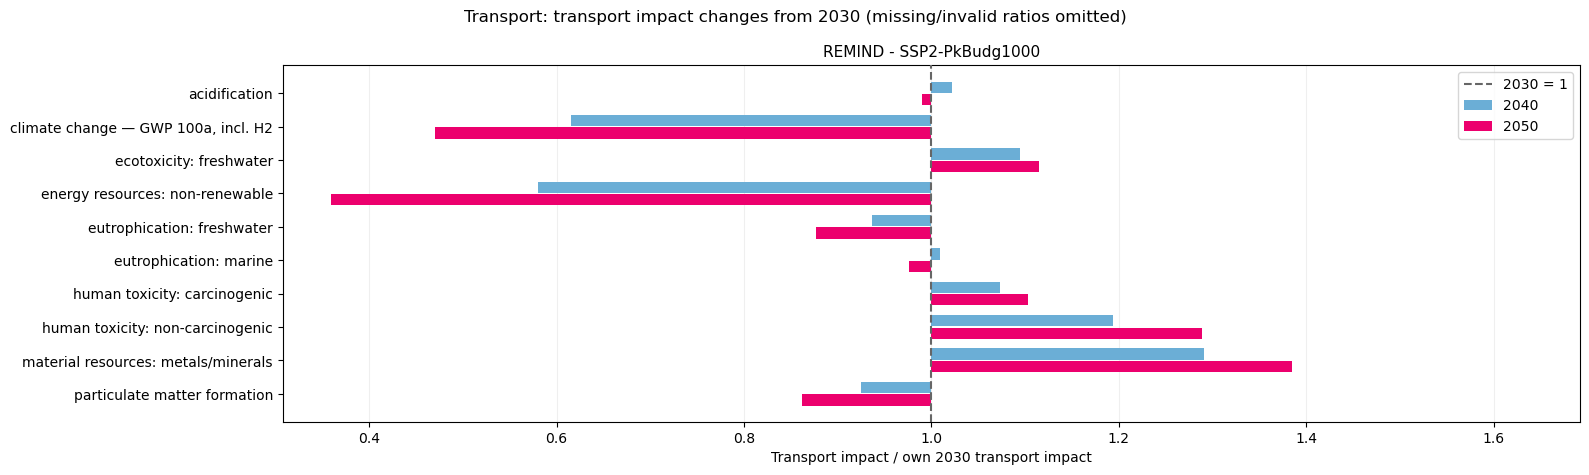

In [28]:
fig, axes = plt.subplots(math.ceil(len(labels) / 3), min(3, len(labels)),
                         squeeze=False, sharex=True, sharey=True,
                         figsize=(16, 4.8 * math.ceil(len(labels) / 3)))
plot_years = [year for year in YEARS if year != BASE_YEAR]
bar_height = 0.75 / max(1, len(plot_years))
# Signed widths start at the baseline, as in the master notebook's barh pattern.
# Use symmetric limits so 1.0 stays in the middle of every scenario panel.
ratios = totals.loc[totals["year"].isin(plot_years), "normalized"].to_numpy(dtype=float)
finite_ratios = ratios[np.isfinite(ratios)]
half_range = max(0.1, float(np.max(np.abs(finite_ratios - 1.0))) * 1.08) if finite_ratios.size else 0.1
for ax, scenario in zip(axes.flat, labels):
    subset = totals.loc[totals["scenario"] == scenario]
    for i, year in enumerate(plot_years):
        values = subset.loc[subset["year"] == year].set_index("impact category")
        values = values.reindex(categories)["normalized"]
        offset = (i - (len(plot_years) - 1) / 2) * bar_height
        ax.barh(np.arange(len(categories)) + offset, values - 1.0, left=1.0,
                height=bar_height * 0.9,
                color=mapping.YEAR_COLORS.get(year, "black"), label=str(year), zorder=2)
    ax.axvline(1, color="0.4", ls="--", label=f"{BASE_YEAR} = 1", zorder=3)
    ax.set_title(scenario)
    ax.set_yticks(range(len(categories)), categories)
    ax.set_xlabel("Transport impact / own 2030 transport impact")
    ax.grid(axis="x", alpha=0.2, zorder=0)
    ax.set_xlim(1.0 - half_range, 1.0 + half_range)
    ax.legend()
axes.flat[0].invert_yaxis()
for ax in list(axes.flat)[len(labels):]:
    ax.set_visible(False)
fig.suptitle(f"{SECTOR}: transport impact changes from 2030 (missing/invalid ratios omitted)")
fig.tight_layout()
plt.show()


## 7. Companion view: transport, conditioning and leakage

This shows whether a reduction in transport-service impacts is accompanied by higher conversion/reconversion impacts. Leakage is kept separate and includes mapped direct market leakage; it is not automatically assigned to a transport mode. Production remains excluded. See the selection and reconciliation tables before interpreting changes.

Run section 5 first after editing plot settings: it defines the shared plotting function used here. Both sections show all impact categories together in one figure per scenario.


In [ ]:
companion = distribution.copy()
companion["group"] = np.where(
    companion["contribution type"].isin(mapping.LEAKAGE_CONTRIBUTION_TYPES),
    companion["contribution type"], companion["substage"])
groups = ["Transport", "Conversion", "Reconversion", *mapping.LEAKAGE_CONTRIBUTION_TYPES]
colors = dict(zip(groups[:3], cfg.ACCESSIBLE_CATEGORICAL_COLORS[:3]))
colors.update(mapping.LEAKAGE_COLORS)
hatches = {"Transport": mapping.PROCESS_HATCH["Distribution"],
           "Conversion": mapping.PROCESS_HATCH["Conversion"],
           "Reconversion": mapping.PROCESS_HATCH["Reconversion"],
           **{g: mapping.PROCESS_HATCH["Hydrogen leakage"]
              for g in mapping.LEAKAGE_CONTRIBUTION_TYPES}}
plot_stacks(companion, "group", groups, colors, hatches,
            "transport, conditioning and direct leakage")
